# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [85]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [117]:
instrument_id = '511520'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_threshold': 2,
    'close_confidence': 1,  
    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 900,

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [118]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=23,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 57
交易日范围: 20251201 ~ 20260227
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=23,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [119]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 768 个样本
20260106: 产生 851 个样本
20260107: 产生 799 个样本
20260108: 产生 775 个样本
20260109: 产生 747 个样本
20260112: 产生 812 个样本
20260113: 产生 626 个样本
20260114: 产生 793 个样本
20260115: 产生 679 个样本
20260116: 产生 665 个样本
20260119: 产生 842 个样本
20260120: 产生 698 个样本
20260121: 产生 804 个样本
20260122: 产生 664 个样本
20260123: 产生 701 个样本
20260126: 产生 832 个样本
20260127: 产生 687 个样本
20260128: 产生 727 个样本
20260129: 产生 727 个样本
20260130: 产生 767 个样本
20260202: 产生 812 个样本
20260203: 产生 702 个样本
20260204: 产生 731 个样本
20260205: 产生 678 个样本
20260206: 产生 618 个样本
20260209: 产生 796 个样本
20260210: 产生 660 个样本
20260211: 产生 730 个样本
20260212: 产生 598 个样本
20260213: 产生 685 个样本
20260224: 产生 678 个样本
20260225: 产生 730 个样本
20260226: 产生 777 个样本
20260227: 产生 610 个样本
训练集样本: X=(24769, 12), y=(24769,)


In [120]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 735 个样本
验证集样本: X=(735, 12), y=(735,)


In [121]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 735 个样本
20251202: 产生 735 个样本
20251203: 产生 705 个样本
20251204: 产生 828 个样本
20251205: 产生 776 个样本
20251208: 产生 803 个样本
20251209: 产生 698 个样本
20251210: 产生 702 个样本
20251211: 产生 632 个样本
20251212: 产生 700 个样本
20251215: 产生 719 个样本
20251216: 产生 782 个样本
20251217: 产生 810 个样本
20251218: 产生 772 个样本
20251219: 产生 725 个样本
20251222: 产生 787 个样本
20251223: 产生 853 个样本
20251224: 产生 755 个样本
20251225: 产生 754 个样本
20251226: 产生 750 个样本
20251229: 产生 825 个样本
20251230: 产生 706 个样本
20251231: 产生 744 个样本
测试集样本: X=(17296, 12), y=(17296,)


## 训练模型

In [122]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.42763


[100]	validation_0-logloss:0.39748
[200]	validation_0-logloss:0.38498
[300]	validation_0-logloss:0.37972
[400]	validation_0-logloss:0.37739
[500]	validation_0-logloss:0.37593
[600]	validation_0-logloss:0.37443
[700]	validation_0-logloss:0.37397
[800]	validation_0-logloss:0.37360
[900]	validation_0-logloss:0.37253
[1000]	validation_0-logloss:0.37243
[1100]	validation_0-logloss:0.37151
[1200]	validation_0-logloss:0.37110
[1300]	validation_0-logloss:0.37001
[1400]	validation_0-logloss:0.36963
[1500]	validation_0-logloss:0.36974
[1600]	validation_0-logloss:0.36950
[1700]	validation_0-logloss:0.36909
[1800]	validation_0-logloss:0.36932
[1900]	validation_0-logloss:0.36887
[1999]	validation_0-logloss:0.36936
阈值优化完成: Best Threshold=0.2873, F0.5=0.2572

特征重要性（前10个）:
volatility    0.175551
alpha_03      0.088051
WAMP          0.088009
alpha_07      0.084836
volume        0.082260
alpha_01      0.073840
alpha_04      0.072219
alpha_02      0.072138
alpha_06      0.071888
spread        0.067390
dt

In [123]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511520_dev.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.7113

分类报告:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82     15300
           1       0.18      0.41      0.25      1996

    accuracy                           0.71     17296
   macro avg       0.54      0.58      0.53     17296
weighted avg       0.82      0.71      0.76     17296


PR曲线AUC: 0.1761
平均精度 (AP): 0.1764

预测概率统计:
  均值: 0.2245
  标准差: 0.1064
  最小值: 0.0037
  25%分位数: 0.1507
  中位数: 0.2154
  75%分位数: 0.2932
  最大值: 0.7415

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.2190, 标准差=0.1046
  标签1 (正类): 均值=0.2667, 标准差=0.1109


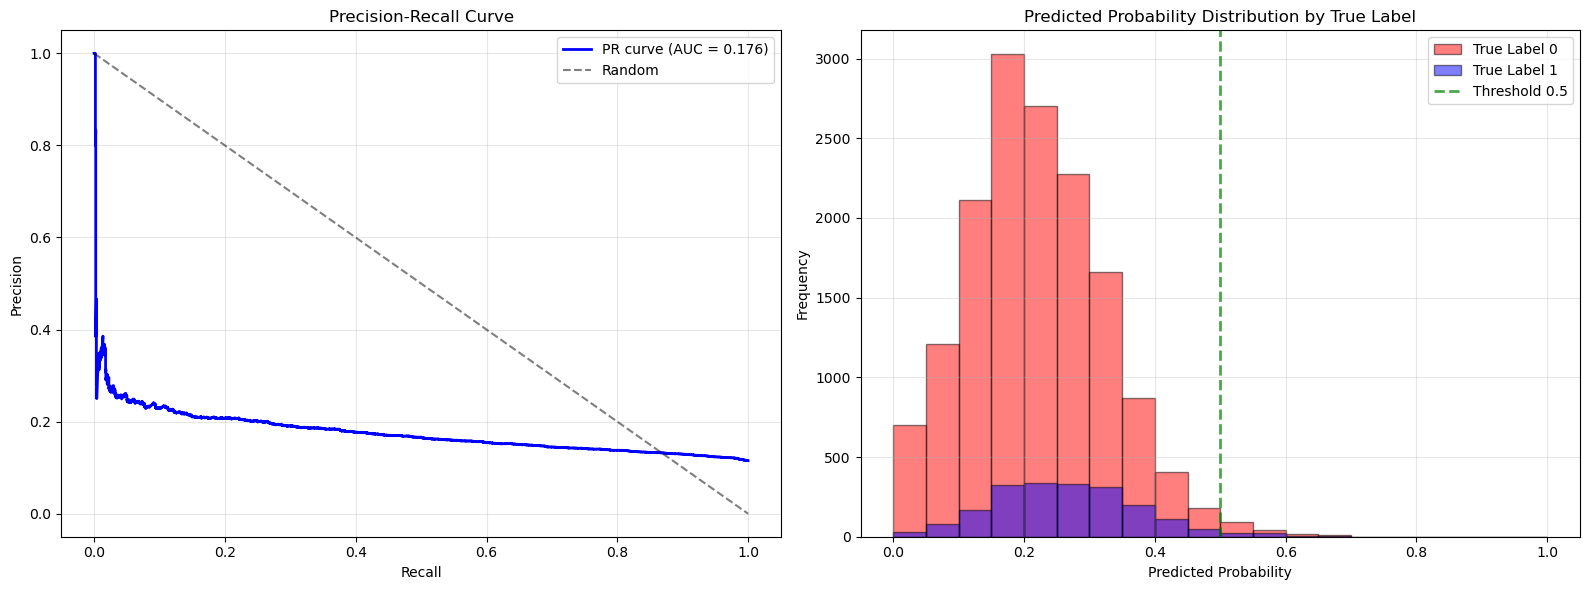

In [124]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [125]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 511520 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-68] 日期 20251225 完成 | 盈亏: 7.30 | 成交: 6次 | 胜率: 83.3% | 平均持仓: 2032.8快照
[SpawnPoolWorker-67] 日期 20251217 完成 | 盈亏: -5.30 | 成交: 12次 | 胜率: 25.0% | 平均持仓: 743.4快照
[SpawnPoolWorker-65] 日期 20251209 完成 | 盈亏: 3.10 | 成交: 8次 | 胜率: 37.5% | 平均持仓: 1493.0快照
[SpawnPoolWorker-66] 日期 20251201 完成 | 盈亏: -0.20 | 成交: 11次 | 胜率: 18.2% | 平均持仓: 900.2快照
[SpawnPoolWorker-67] 日期 20251218 完成 | 盈亏: 10.70 | 成交: 4次 | 胜率: 100.0% | 平均持仓: 2697.2快照
[SpawnPoolWorker-68] 日期 20251226 完成 | 盈亏: 4.20 | 成交: 8次 | 胜率: 62.5% | 平均持仓: 1446.6快照
[SpawnPoolWorker-65] 日期 20251210 完成 | 盈亏: 4.20 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 1143.0快照
[SpawnPoolWorker-66] 日期 20251202 完成 | 盈亏: 5.90 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 1097.2快照
[SpawnPoolWorker-67] 日期 20251219 完成 | 盈亏: -3.30 | 成交: 8次 | 胜率: 37.5% | 平均持仓: 1067.6快照
[SpawnPoolWorker-65] 日期 20251211 完成 | 盈亏: 4.90 | 成交: 8次 | 胜率: 50.0% | 平均持仓: 1561.8快照
[SpawnPoolWorker-68] 日期 20251229 完成 | 盈亏: -5.20 | 成交: 9次 | 胜率: 33.3% | 平均持仓: 1034.9快照
[SpawnPoolWorker-66] 日期 20251203 完成 | 盈亏: 4.20 | 成交: 9次 |

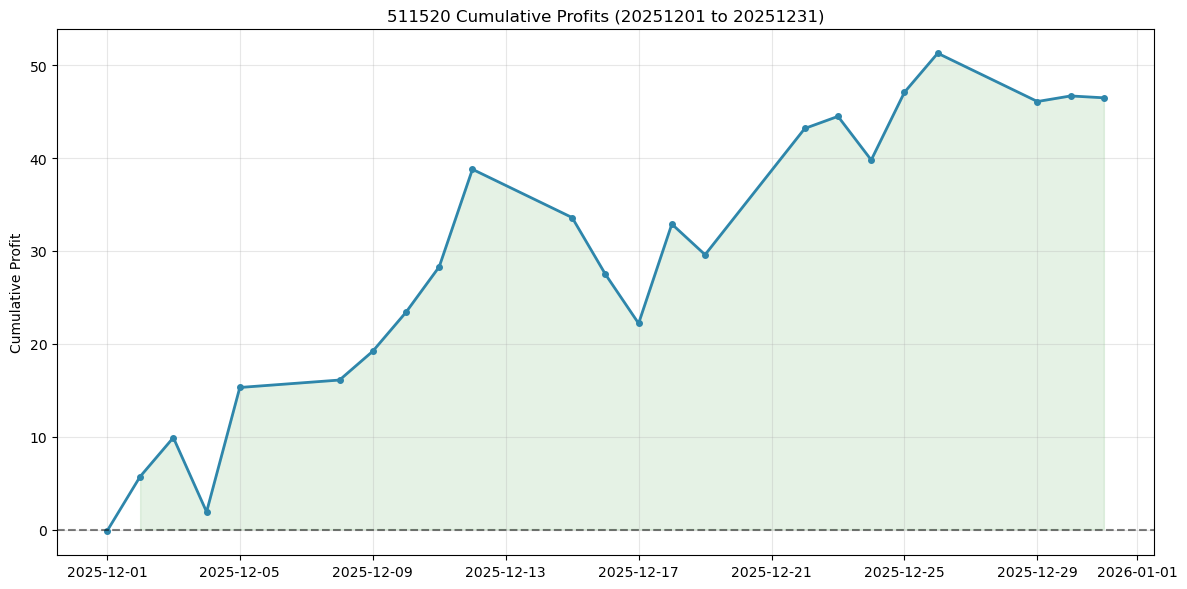


并行回测结果汇总:


In [126]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

In [128]:
print(summary)

{'测试天数': 23, '累计总盈亏': np.float64(46.5), '总成交次数': 190, '盈利交易次数': 75, '亏损交易次数': 115, '加权每手胜率%': np.float64(39.47), '日均盈亏': np.float64(2.02), '胜率(天)%': 60.87, '盈亏比(日均)': np.float64(1.43), '最大单日盈利': 13.6, '最大单日亏损': -8.0, '每笔交易平均盈利': np.float64(0.24), '加权平均持仓时间(快照)': np.float64(1208.3)}


## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [129]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260414", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_025053
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_042231
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_011936
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_061311

总共删除了 4 个文件夹


## 单日回测观察

In [624]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20260303',StrategyDemo,model_path,param_dict,official = False)


instrument_id 511090
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
20251217
20251218
20251219
20251222
20251223
20251224
20251225
20251226
20251229
20251230
20251231
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227

instrument_id 511100
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
20251217
20251218
20251219
20251222
20251223
20251224
20251225
20251226
20251229
20251230
20251231
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20

SystemExit: 

/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


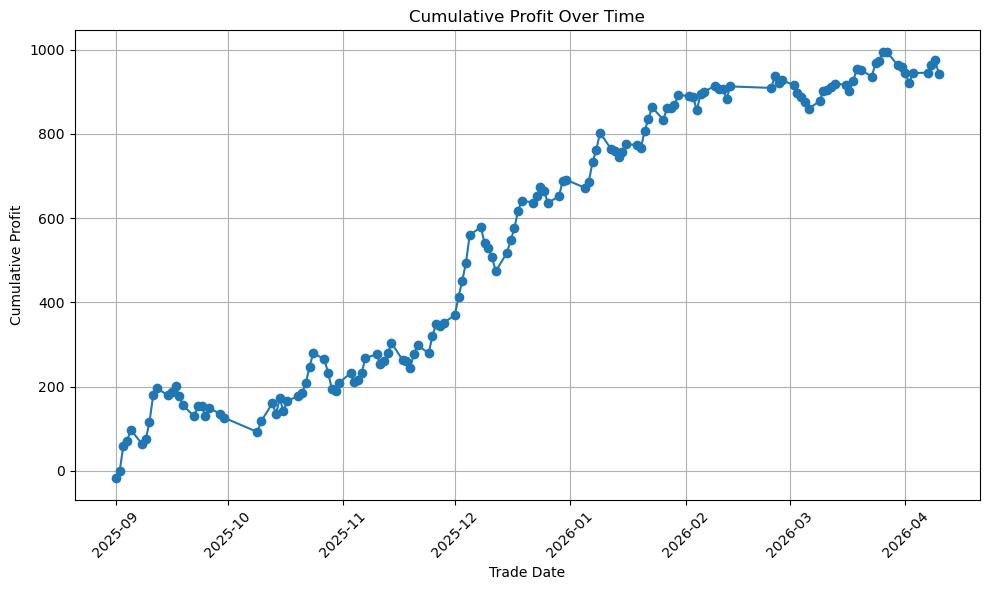

In [148]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
